# GDiM Eurogate FLS26

This notebook consolidates the project markdown notes and Python pipeline into one sequential, easy-to-run workflow for the **Reefer Load Outlook Challenge**.

## Challenge Summary

From the project markdown files:

- The task is to forecast **hourly combined reefer electricity demand** for the released timestamps in `target_timestamps.csv`.
- The submission must contain `pred_power_kw` and `pred_p90_kw`, where `pred_p90_kw >= pred_power_kw`.
- The challenge score is:

```text
score = 0.5 * mae_all + 0.3 * mae_peak + 0.2 * pinball_p90
```

- The solution must be **24-hour-ahead and leak-safe**, using no future information.
- The real CSV schema differs slightly from the markdown data dictionary, so this notebook follows the actual files and column names in the repo such as `container_visit_uuid`, `AvPowerCons`, and `RemperatureSupply`.

## Notebook Flow

1. Loading the data
2. Pre-processing the data
3. Initial data analysis
4. Train, validation, and submission split
5. Build model
6. Train model
7. Evaluate model
8. Pick the best model
9. Create `predictions.csv` for submission


In [1]:
import json
import os
import pickle
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('VECLIB_MAXIMUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp')

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import GradientBoostingRegressor

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid', context='talk')

ROOT = Path.cwd().resolve()
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
TARGET_FILE = 'target_timestamps.csv'
REEFER_FILE = 'reefer_release.csv'
WEATHER_DIR_NAME = 'Wetterdaten Okt 25 - 23 Feb 26'

REEFER_USECOLS = [
    'container_visit_uuid',
    'HardwareType',
    'EventTime',
    'AvPowerCons',
    'TemperatureSetPoint',
    'TemperatureAmbient',
    'TemperatureReturn',
    'RemperatureSupply',
    'ContainerSize',
    'stack_tier',
]

CATEGORY_PREFIXES = {
    'HardwareType': 'hardware',
    'ContainerSize': 'size',
    'stack_tier': 'tier',
}

WEATHER_FILE_LABELS = {
    'CTH_Temperatur_VC_Halle3 Okt 25 - 23 Feb 26.csv': 'temperature_vc_halle3',
    'CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26.csv': 'temperature_zentralgate',
    'CTH_Wind_VC_Halle3  Okt 25 - 23 Feb 26.csv': 'wind_vc_halle3',
    'CTH_Wind_Zentralgate  Okt 25 - 23 Feb 26.csv': 'wind_zentralgate',
    'CTH_Windrichtung_VC_Halle3  Okt 25 - 23 Feb 26.csv': 'wind_direction_vc_halle3',
    'CTH_Windrichtung_Zentralgate  Okt 25 - 23 Feb 26.csv': 'wind_direction_zentralgate',
}

print(f'Project root: {ROOT}')


Project root: /Users/yash1010/Documents/GitHub/GDiM-Eurogate-Challenge


In [2]:
@dataclass
class ProjectPaths:
    root: Path
    reefer_csv: Path
    weather_dir: Path
    target_csv: Path

    @classmethod
    def from_root(cls, root: Path) -> 'ProjectPaths':
        root = root.resolve()
        return cls(
            root=root,
            reefer_csv=root / REEFER_FILE,
            weather_dir=root / WEATHER_DIR_NAME,
            target_csv=root / TARGET_FILE,
        )

    def validate(self) -> None:
        missing = [
            path
            for path in [self.reefer_csv, self.weather_dir, self.target_csv]
            if not path.exists()
        ]
        if missing:
            missing_text = ', '.join(str(path) for path in missing)
            raise FileNotFoundError(f'Missing required project inputs: {missing_text}')


@dataclass
class FoldResult:
    fold_name: str
    train_rows: int
    valid_rows: int
    mae_all: float
    mae_peak: float
    pinball_p90: float
    score: float


@dataclass
class SavedModelArtifact:
    bundle: 'ResidualModelBundle'
    calibrator: 'ResidualCalibrator'
    best_result: FoldResult


@dataclass
class ResidualModelBundle:
    model: GradientBoostingRegressor
    feature_columns: list[str]
    preprocessor: 'FeaturePreprocessor'


@dataclass
class FeaturePreprocessor:
    strategy: str
    feature_columns: list[str]
    impute_values: pd.Series
    clip_lower: pd.Series
    clip_upper: pd.Series
    scale_mean: pd.Series
    scale_std: pd.Series
    scaled_columns: list[str]


@dataclass
class ResidualCalibrator:
    bin_edges: np.ndarray
    global_q90: float
    hour_q90: dict[int, float]
    hour_bin_q90: dict[tuple[int, int], float]

    @staticmethod
    def _assign_bins(values: np.ndarray, bin_edges: np.ndarray) -> np.ndarray:
        if len(bin_edges) <= 2:
            return np.zeros(len(values), dtype=int)
        raw = np.digitize(values, bin_edges[1:-1], right=True)
        return raw.astype(int)

    @classmethod
    def fit(
        cls,
        timestamps: pd.Series,
        pred_power_kw: pd.Series,
        actual_kw: pd.Series,
        *,
        min_samples_per_bin: int = 25,
    ) -> 'ResidualCalibrator':
        calibration = pd.DataFrame(
            {
                'timestamp_utc': pd.to_datetime(timestamps),
                'pred_power_kw': pred_power_kw.astype(float),
                'actual_kw': actual_kw.astype(float),
            }
        ).dropna()
        if calibration.empty:
            return cls(
                bin_edges=np.array([0.0, 1.0], dtype=float),
                global_q90=0.0,
                hour_q90={},
                hour_bin_q90={},
            )

        calibration['positive_residual'] = np.maximum(
            calibration['actual_kw'] - calibration['pred_power_kw'], 0.0
        )
        calibration['hour'] = calibration['timestamp_utc'].dt.hour

        quantiles = np.linspace(0.0, 1.0, 11)
        bin_edges = np.unique(np.quantile(calibration['pred_power_kw'], quantiles))
        if len(bin_edges) < 2:
            bin_edges = np.array(
                [
                    float(calibration['pred_power_kw'].min()),
                    float(calibration['pred_power_kw'].max()) + 1.0,
                ]
            )

        calibration['pred_bin'] = cls._assign_bins(
            calibration['pred_power_kw'].to_numpy(),
            bin_edges,
        )
        global_q90 = float(calibration['positive_residual'].quantile(0.9))

        hour_q90 = (
            calibration.groupby('hour')['positive_residual']
            .quantile(0.9)
            .astype(float)
            .to_dict()
        )

        grouped = calibration.groupby(['hour', 'pred_bin'])['positive_residual']
        hour_bin_q90: dict[tuple[int, int], float] = {}
        for key, values in grouped:
            if len(values) >= min_samples_per_bin:
                hour_bin_q90[key] = float(values.quantile(0.9))

        return cls(
            bin_edges=bin_edges.astype(float),
            global_q90=global_q90,
            hour_q90=hour_q90,
            hour_bin_q90=hour_bin_q90,
        )

    def predict_adjustment(
        self,
        timestamps: pd.Series,
        pred_power_kw: pd.Series,
    ) -> np.ndarray:
        timestamps = pd.to_datetime(timestamps)
        pred_values = pred_power_kw.astype(float).to_numpy()
        pred_bins = self._assign_bins(pred_values, self.bin_edges)
        hours = timestamps.dt.hour.to_numpy()

        adjustments: list[float] = []
        for hour, pred_bin in zip(hours, pred_bins):
            adjustments.append(
                self.hour_bin_q90.get(
                    (int(hour), int(pred_bin)),
                    self.hour_q90.get(int(hour), self.global_q90),
                )
            )
        return np.asarray(adjustments, dtype=float)


In [3]:
def sanitize_name(text: str) -> str:
    slug = re.sub(r'[^a-z0-9]+', '_', text.strip().lower())
    return slug.strip('_') or 'missing'


def load_target_hours(target_csv: Path) -> pd.Series:
    targets = pd.read_csv(target_csv, parse_dates=['timestamp_utc'])
    if pd.api.types.is_datetime64tz_dtype(targets['timestamp_utc']):
        targets['timestamp_utc'] = targets['timestamp_utc'].dt.tz_localize(None)
    if targets['timestamp_utc'].duplicated().any():
        raise ValueError('target_timestamps.csv contains duplicates.')
    if not targets['timestamp_utc'].is_monotonic_increasing:
        raise ValueError('target_timestamps.csv must be sorted ascending.')
    return targets['timestamp_utc']


def aggregate_reefer_hourly(reefer_csv: Path) -> pd.DataFrame:
    dtypes = {
        'container_visit_uuid': 'string',
        'HardwareType': 'string',
        'ContainerSize': 'string',
        'stack_tier': 'string',
    }
    reefer = pd.read_csv(
        reefer_csv,
        sep=';',
        decimal=',',
        parse_dates=['EventTime'],
        usecols=REEFER_USECOLS,
        dtype=dtypes,
        na_values=['NULL', ''],
        keep_default_na=True,
        low_memory=False,
    )

    reefer = reefer.rename(columns={'EventTime': 'timestamp_utc'})
    reefer['timestamp_utc'] = reefer['timestamp_utc'].dt.floor('H')
    reefer['stack_tier'] = reefer['stack_tier'].str.strip()
    reefer['stack_tier'] = reefer['stack_tier'].replace('', pd.NA)
    reefer['y_kw'] = reefer['AvPowerCons'] / 1000.0

    hourly = reefer.groupby('timestamp_utc').agg(
        y_kw=('y_kw', 'sum'),
        obs_active_container_count=('container_visit_uuid', 'size'),
        obs_temp_setpoint_mean=('TemperatureSetPoint', 'mean'),
        obs_temp_setpoint_median=('TemperatureSetPoint', 'median'),
        obs_temp_ambient_mean=('TemperatureAmbient', 'mean'),
        obs_temp_ambient_median=('TemperatureAmbient', 'median'),
        obs_temp_return_mean=('TemperatureReturn', 'mean'),
        obs_temp_return_median=('TemperatureReturn', 'median'),
        obs_temp_supply_mean=('RemperatureSupply', 'mean'),
        obs_temp_supply_median=('RemperatureSupply', 'median'),
    )

    for column_name, prefix in CATEGORY_PREFIXES.items():
        counts = pd.crosstab(
            reefer['timestamp_utc'],
            reefer[column_name].fillna('missing'),
            dropna=False,
        )
        counts = counts.rename(
            columns=lambda value: f'obs_{prefix}_count_{sanitize_name(str(value))}'
        )
        shares = counts.div(hourly['obs_active_container_count'], axis=0)
        shares = shares.rename(
            columns=lambda value: value.replace('_count_', '_share_')
        )
        hourly = hourly.join(counts, how='left').join(shares, how='left')

    return hourly.sort_index()


def weather_label(path: Path) -> str:
    return WEATHER_FILE_LABELS.get(path.name, sanitize_name(path.stem))


def aggregate_single_weather_file(weather_csv: Path) -> pd.DataFrame:
    label = weather_label(weather_csv)
    weather = pd.read_csv(
        weather_csv,
        sep=';',
        decimal=',',
        parse_dates=['UtcTimestamp'],
        usecols=['UtcTimestamp', 'Value'],
        na_values=['NULL', ''],
        keep_default_na=True,
        low_memory=False,
    )

    weather = weather.dropna(subset=['UtcTimestamp'])
    weather['timestamp_utc'] = weather['UtcTimestamp'].dt.floor('H')

    if 'wind_direction' in label:
        radians = np.deg2rad(weather['Value'].astype(float))
        weather['sin_value'] = np.sin(radians)
        weather['cos_value'] = np.cos(radians)
        hourly = weather.groupby('timestamp_utc').agg(
            **{
                f'obs_weather_{label}_sin_mean': ('sin_value', 'mean'),
                f'obs_weather_{label}_cos_mean': ('cos_value', 'mean'),
            }
        )
    else:
        hourly = weather.groupby('timestamp_utc').agg(
            **{
                f'obs_weather_{label}_mean': ('Value', 'mean'),
                f'obs_weather_{label}_max': ('Value', 'max'),
                f'obs_weather_{label}_min': ('Value', 'min'),
            }
        )

    return hourly.sort_index()


def aggregate_weather_hourly(weather_dir: Path) -> pd.DataFrame:
    frames = [
        aggregate_single_weather_file(path)
        for path in sorted(weather_dir.glob('*.csv'))
    ]
    if not frames:
        raise FileNotFoundError(f'No weather CSV files found in {weather_dir}')
    weather = pd.concat(frames, axis=1).sort_index()
    return weather


def build_hourly_observation_table(paths: ProjectPaths) -> pd.DataFrame:
    targets = load_target_hours(paths.target_csv)
    reefer_hourly = aggregate_reefer_hourly(paths.reefer_csv)
    weather_hourly = aggregate_weather_hourly(paths.weather_dir)

    min_hour = min(reefer_hourly.index.min(), weather_hourly.index.min(), targets.min())
    max_hour = max(reefer_hourly.index.max(), weather_hourly.index.max(), targets.max())
    full_index = pd.date_range(min_hour, max_hour, freq='H')

    table = pd.DataFrame(index=full_index)
    table.index.name = 'timestamp_utc'
    table = table.join(reefer_hourly, how='left')
    table = table.join(weather_hourly, how='left')
    table['is_public_target'] = table.index.isin(set(targets))
    return table


def add_model_features(observations: pd.DataFrame) -> pd.DataFrame:
    df = observations.copy().sort_index()
    index = df.index
    feature_data: dict[str, pd.Series | np.ndarray] = {}

    feature_data['feat_hour'] = index.hour
    feature_data['feat_day_of_week'] = index.dayofweek
    feature_data['feat_month'] = index.month
    feature_data['feat_day_of_year'] = index.dayofyear
    feature_data['feat_is_weekend'] = (index.dayofweek >= 5).astype(int)
    feature_data['feat_hour_sin'] = np.sin(2 * np.pi * index.hour / 24.0)
    feature_data['feat_hour_cos'] = np.cos(2 * np.pi * index.hour / 24.0)
    feature_data['feat_dow_sin'] = np.sin(2 * np.pi * index.dayofweek / 7.0)
    feature_data['feat_dow_cos'] = np.cos(2 * np.pi * index.dayofweek / 7.0)

    target = df['y_kw']
    lag_24 = target.shift(24)
    lag_48 = target.shift(48)
    lag_72 = target.shift(72)
    lag_168 = target.shift(168)
    target_shifted = target.shift(24)

    feature_data['feat_lag_24'] = lag_24
    feature_data['feat_lag_48'] = lag_48
    feature_data['feat_lag_72'] = lag_72
    feature_data['feat_lag_168'] = lag_168
    feature_data['feat_roll24_mean'] = target_shifted.rolling(24, min_periods=12).mean()
    feature_data['feat_roll24_max'] = target_shifted.rolling(24, min_periods=12).max()
    feature_data['feat_roll24_min'] = target_shifted.rolling(24, min_periods=12).min()
    feature_data['feat_roll24_std'] = target_shifted.rolling(24, min_periods=12).std()
    feature_data['feat_roll72_mean'] = target_shifted.rolling(72, min_periods=24).mean()
    feature_data['feat_roll72_max'] = target_shifted.rolling(72, min_periods=24).max()
    feature_data['feat_roll72_min'] = target_shifted.rolling(72, min_periods=24).min()
    feature_data['feat_roll72_std'] = target_shifted.rolling(72, min_periods=24).std()
    feature_data['feat_roll168_mean'] = target_shifted.rolling(168, min_periods=48).mean()
    feature_data['feat_roll168_max'] = target_shifted.rolling(168, min_periods=48).max()
    feature_data['feat_roll168_min'] = target_shifted.rolling(168, min_periods=48).min()
    feature_data['feat_roll168_std'] = target_shifted.rolling(168, min_periods=48).std()
    feature_data['feat_delta_24_48'] = lag_24 - lag_48
    feature_data['feat_delta_24_168'] = lag_24 - lag_168
    feature_data['feat_trend_24_72'] = lag_24 - feature_data['feat_roll72_mean']
    feature_data['feat_trend_24_168'] = lag_24 - feature_data['feat_roll168_mean']
    feature_data['baseline_pred_kw'] = 0.7 * lag_24 + 0.3 * lag_168

    observation_columns = [
        column
        for column in df.columns
        if column.startswith('obs_') and column != 'y_kw'
    ]
    reefer_columns = [
        column for column in observation_columns if not column.startswith('obs_weather_')
    ]
    weather_columns = [
        column for column in observation_columns if column.startswith('obs_weather_')
    ]

    for column in reefer_columns:
        feature_data[f'feat_{column}_lag24'] = df[column].shift(24)
        feature_data[f'feat_{column}_lag168'] = df[column].shift(168)

    for column in weather_columns:
        shifted = df[column].shift(24)
        feature_data[f'feat_{column}_lag24'] = shifted
        feature_data[f'feat_{column}_lag48'] = df[column].shift(48)
        feature_data[f'feat_{column}_lag168'] = df[column].shift(168)
        feature_data[f'feat_{column}_roll24_mean'] = shifted.rolling(24, min_periods=6).mean()
        feature_data[f'feat_{column}_roll24_max'] = shifted.rolling(24, min_periods=6).max()
        feature_data[f'feat_{column}_roll24_min'] = shifted.rolling(24, min_periods=6).min()
        feature_data[f'feat_{column}_roll168_mean'] = shifted.rolling(168, min_periods=24).mean()

    features = pd.DataFrame(feature_data, index=df.index)

    feature_table = pd.concat(
        [
            df[['y_kw', 'is_public_target']],
            df.drop(columns=['is_public_target', 'y_kw'], errors='ignore'),
            features,
        ],
        axis=1,
    )
    feature_table.index.name = 'timestamp_utc'
    return feature_table


def build_feature_table(paths: ProjectPaths) -> pd.DataFrame:
    observations = build_hourly_observation_table(paths)
    return add_model_features(observations)


def get_feature_columns(feature_table: pd.DataFrame) -> list[str]:
    return [
        column
        for column in feature_table.columns
        if column.startswith('feat_') or column == 'baseline_pred_kw'
    ]


def get_model_rows(feature_table: pd.DataFrame) -> pd.DataFrame:
    rows = feature_table.copy()
    rows = rows[rows['y_kw'].notna()]
    rows = rows[rows['baseline_pred_kw'].notna()]
    return rows.sort_index()


def make_validation_folds(
    feature_table: pd.DataFrame,
    *,
    n_folds: int = 4,
    fold_hours: int = 24 * 7,
) -> list[tuple[str, pd.Timestamp, pd.Timestamp]]:
    usable = get_model_rows(feature_table)
    if len(usable) < n_folds * fold_hours:
        raise ValueError('Not enough trainable rows for the requested backtest folds.')

    valid_end = usable.index.max()
    folds: list[tuple[str, pd.Timestamp, pd.Timestamp]] = []
    for offset in range(n_folds):
        fold_end = valid_end - pd.Timedelta(hours=fold_hours * offset)
        fold_start = fold_end - pd.Timedelta(hours=fold_hours - 1)
        folds.append((f'fold_{n_folds - offset}', fold_start, fold_end))
    return list(reversed(folds))


def select_training_columns(
    train_frame: pd.DataFrame,
    feature_columns: Iterable[str],
) -> list[str]:
    selected: list[str] = []
    for column in feature_columns:
        series = train_frame[column]
        if series.notna().sum() == 0:
            continue
        if series.nunique(dropna=True) <= 1:
            continue
        selected.append(column)
    if not selected:
        raise ValueError('No informative model features were available.')
    return selected


In [4]:
def fit_feature_preprocessor(
    train_frame: pd.DataFrame,
    feature_columns: list[str],
) -> FeaturePreprocessor:
    x_train = train_frame[feature_columns].copy()
    x_train = x_train.replace([np.inf, -np.inf], np.nan)
    impute_values = x_train.median(numeric_only=True)
    x_imputed = x_train.fillna(impute_values)

    clip_lower = x_imputed.quantile(0.005)
    clip_upper = x_imputed.quantile(0.995)
    x_clipped = x_imputed.clip(lower=clip_lower, upper=clip_upper, axis=1)

    scale_mean = x_clipped.mean()
    scale_std = x_clipped.std(ddof=0).replace(0.0, 1.0)

    scaled_columns: list[str] = []
    for column in feature_columns:
        unique_values = pd.Series(x_clipped[column].dropna().unique())
        if unique_values.empty:
            continue
        if set(unique_values.tolist()).issubset({0, 1}):
            continue
        if float(scale_std[column]) <= 0.0:
            continue
        scaled_columns.append(column)

    return FeaturePreprocessor(
        strategy='median_clip_scale',
        feature_columns=feature_columns,
        impute_values=impute_values,
        clip_lower=clip_lower,
        clip_upper=clip_upper,
        scale_mean=scale_mean,
        scale_std=scale_std,
        scaled_columns=scaled_columns,
    )


def transform_features(
    frame: pd.DataFrame,
    preprocessor: FeaturePreprocessor,
) -> pd.DataFrame:
    x_frame = frame[preprocessor.feature_columns].copy()
    x_frame = x_frame.replace([np.inf, -np.inf], np.nan)
    x_frame = x_frame.fillna(preprocessor.impute_values)
    x_frame = x_frame.clip(
        lower=preprocessor.clip_lower,
        upper=preprocessor.clip_upper,
        axis=1,
    )
    if preprocessor.scaled_columns:
        x_frame = x_frame.astype(
            {column: 'float64' for column in preprocessor.scaled_columns},
            copy=False,
        )
        x_frame.loc[:, preprocessor.scaled_columns] = (
            x_frame[preprocessor.scaled_columns] - preprocessor.scale_mean[preprocessor.scaled_columns]
        ) / preprocessor.scale_std[preprocessor.scaled_columns]
    return x_frame


def build_model_ready_feature_table(
    feature_table: pd.DataFrame,
    preprocessor: FeaturePreprocessor,
) -> pd.DataFrame:
    processed = transform_features(feature_table, preprocessor)
    model_ready = pd.concat(
        [
            feature_table[['y_kw', 'is_public_target']],
            processed,
        ],
        axis=1,
    )
    model_ready.index.name = 'timestamp_utc'
    return model_ready


def preprocessing_summary(preprocessor: FeaturePreprocessor) -> dict[str, int]:
    return {
        'strategy': preprocessor.strategy,
        'feature_count': len(preprocessor.feature_columns),
        'scaled_feature_count': len(preprocessor.scaled_columns),
        'imputed_feature_count': int((preprocessor.impute_values.notna()).sum()),
    }


def fit_residual_model(
    train_frame: pd.DataFrame,
    feature_columns: list[str],
) -> ResidualModelBundle:
    selected_columns = select_training_columns(train_frame, feature_columns)
    residual = train_frame['y_kw'] - train_frame['baseline_pred_kw']
    peak_threshold = float(train_frame['y_kw'].quantile(0.9))
    sample_weight = np.where(train_frame['y_kw'] >= peak_threshold, 2.0, 1.0)
    preprocessor = fit_feature_preprocessor(train_frame, selected_columns)
    x_train = transform_features(train_frame, preprocessor)

    model = GradientBoostingRegressor(
        loss='absolute_error',
        learning_rate=0.05,
        max_depth=2,
        n_estimators=120,
        min_samples_leaf=30,
        subsample=0.8,
        max_features=0.6,
        random_state=RANDOM_SEED,
    )
    model.fit(x_train, residual, sample_weight=sample_weight)
    return ResidualModelBundle(
        model=model,
        feature_columns=selected_columns,
        preprocessor=preprocessor,
    )


def predict_point_forecast(
    frame: pd.DataFrame,
    bundle: ResidualModelBundle,
) -> np.ndarray:
    x_frame = transform_features(frame, bundle.preprocessor)
    residual_pred = bundle.model.predict(x_frame)
    point_pred = frame['baseline_pred_kw'].to_numpy(dtype=float) + residual_pred
    return np.clip(point_pred, 0.0, None)


def pinball_loss(actual: np.ndarray, pred: np.ndarray, quantile: float = 0.9) -> float:
    residual = actual - pred
    return float(
        np.mean(np.where(residual >= 0.0, quantile * residual, (1.0 - quantile) * (-residual)))
    )


def evaluate_predictions(actual: np.ndarray, pred_power: np.ndarray, pred_p90: np.ndarray) -> dict[str, float]:
    mae_all = float(np.mean(np.abs(actual - pred_power)))
    peak_threshold = float(np.quantile(actual, 0.9))
    peak_mask = actual >= peak_threshold
    mae_peak = float(np.mean(np.abs(actual[peak_mask] - pred_power[peak_mask])))
    pinball = pinball_loss(actual, pred_p90, quantile=0.9)
    score = 0.5 * mae_all + 0.3 * mae_peak + 0.2 * pinball
    return {
        'mae_all': mae_all,
        'mae_peak': mae_peak,
        'pinball_p90': pinball,
        'score': float(score),
    }


def run_backtest(
    feature_table: pd.DataFrame,
) -> tuple[list[FoldResult], ResidualModelBundle, ResidualCalibrator, FoldResult]:
    rows = get_model_rows(feature_table)
    feature_columns = get_feature_columns(feature_table)
    folds = make_validation_folds(feature_table)

    fold_results: list[FoldResult] = []
    best_bundle: ResidualModelBundle | None = None
    best_calibrator: ResidualCalibrator | None = None
    best_result: FoldResult | None = None

    for fold_name, fold_start, fold_end in folds:
        train_frame = rows.loc[rows.index < fold_start].copy()
        valid_frame = rows.loc[(rows.index >= fold_start) & (rows.index <= fold_end)].copy()

        print(f'{fold_name}: train_rows={len(train_frame):,}, valid_rows={len(valid_frame):,}')
        bundle = fit_residual_model(train_frame, feature_columns)
        valid_pred = predict_point_forecast(valid_frame, bundle)

        fold_calibration_frame = pd.DataFrame(
            {
                'timestamp_utc': valid_frame.index,
                'actual_kw': valid_frame['y_kw'].to_numpy(dtype=float),
                'pred_power_kw': valid_pred,
            }
        )
        fold_calibrator = ResidualCalibrator.fit(
            fold_calibration_frame['timestamp_utc'],
            fold_calibration_frame['pred_power_kw'],
            fold_calibration_frame['actual_kw'],
        )
        adjustments = fold_calibrator.predict_adjustment(
            fold_calibration_frame['timestamp_utc'],
            fold_calibration_frame['pred_power_kw'],
        )
        pred_p90 = np.maximum(
            fold_calibration_frame['pred_power_kw'].to_numpy(dtype=float),
            fold_calibration_frame['pred_power_kw'].to_numpy(dtype=float) + adjustments,
        )
        metrics = evaluate_predictions(
            fold_calibration_frame['actual_kw'].to_numpy(dtype=float),
            fold_calibration_frame['pred_power_kw'].to_numpy(dtype=float),
            pred_p90,
        )
        fold_result = FoldResult(
            fold_name=fold_name,
            train_rows=int(len(train_frame)),
            valid_rows=int(len(valid_frame)),
            mae_all=metrics['mae_all'],
            mae_peak=metrics['mae_peak'],
            pinball_p90=metrics['pinball_p90'],
            score=metrics['score'],
        )
        fold_results.append(fold_result)
        if best_result is None or fold_result.score < best_result.score:
            best_result = fold_result
            best_bundle = bundle
            best_calibrator = fold_calibrator

    if best_bundle is None or best_calibrator is None or best_result is None:
        raise ValueError('Backtest did not produce a best model.')

    return fold_results, best_bundle, best_calibrator, best_result


def save_model_artifact(
    path: Path,
    bundle: ResidualModelBundle,
    calibrator: ResidualCalibrator,
    best_result: FoldResult,
) -> None:
    artifact = SavedModelArtifact(
        bundle=bundle,
        calibrator=calibrator,
        best_result=best_result,
    )
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('wb') as f:
        pickle.dump(artifact, f)


def generate_submission(
    feature_table: pd.DataFrame,
    bundle: ResidualModelBundle,
    calibrator: ResidualCalibrator,
) -> pd.DataFrame:
    target_frame = feature_table.loc[feature_table['is_public_target']].copy()
    if target_frame.empty:
        raise ValueError('No public target rows were found in the feature table.')

    pred_power = predict_point_forecast(target_frame, bundle)
    adjustments = calibrator.predict_adjustment(
        pd.Series(target_frame.index, index=target_frame.index),
        pd.Series(pred_power, index=target_frame.index),
    )
    pred_p90 = np.maximum(pred_power, pred_power + adjustments)

    submission = pd.DataFrame(
        {
            'timestamp_utc': target_frame.index.strftime('%Y-%m-%dT%H:%M:%SZ'),
            'pred_power_kw': np.round(pred_power, 6),
            'pred_p90_kw': np.round(pred_p90, 6),
        }
    )
    validate_submission(submission)
    return submission


def validate_submission(submission: pd.DataFrame) -> None:
    required_columns = ['timestamp_utc', 'pred_power_kw', 'pred_p90_kw']
    if submission.columns.tolist() != required_columns:
        raise ValueError('Submission columns do not match the required template.')
    if submission['timestamp_utc'].duplicated().any():
        raise ValueError('Submission contains duplicate timestamps.')
    if (submission[['pred_power_kw', 'pred_p90_kw']] < 0).any().any():
        raise ValueError('Submission contains negative predictions.')
    if (submission['pred_p90_kw'] < submission['pred_power_kw']).any():
        raise ValueError('Submission violates pred_p90_kw >= pred_power_kw.')


def serialize_fold_results(results: list[FoldResult]) -> list[dict[str, float | int | str]]:
    return [
        {
            'fold_name': result.fold_name,
            'train_rows': result.train_rows,
            'valid_rows': result.valid_rows,
            'mae_all': result.mae_all,
            'mae_peak': result.mae_peak,
            'pinball_p90': result.pinball_p90,
            'score': result.score,
        }
        for result in results
    ]


def summarize_fold_results(results: list[FoldResult]) -> dict[str, float]:
    return {
        'mae_all': float(np.mean([result.mae_all for result in results])),
        'mae_peak': float(np.mean([result.mae_peak for result in results])),
        'pinball_p90': float(np.mean([result.pinball_p90 for result in results])),
        'score': float(np.mean([result.score for result in results])),
    }


## 1. Loading the data

We first validate the project paths and inspect the raw inputs. The challenge uses:

- `reefer_release.csv` for reefer history
- `Wetterdaten Okt 25 - 23 Feb 26/` for weather history
- `target_timestamps.csv` for the public prediction timestamps


In [5]:
paths = ProjectPaths.from_root(ROOT)
paths.validate()

target_hours = load_target_hours(paths.target_csv)
weather_files = sorted(paths.weather_dir.glob('*.csv'))

reefer_preview = pd.read_csv(
    paths.reefer_csv,
    sep=';',
    decimal=',',
    usecols=REEFER_USECOLS,
    nrows=5,
    low_memory=False,
)

load_summary = pd.DataFrame(
    {
        'artifact': ['reefer_release.csv', 'target_timestamps.csv', 'weather CSV files'],
        'detail': [
            str(paths.reefer_csv),
            str(paths.target_csv),
            str(paths.weather_dir),
        ],
        'count_or_rows': [
            f'preview only here; full file loaded in the next step',
            len(target_hours),
            len(weather_files),
        ],
    }
)

display(load_summary)
display(pd.DataFrame({'target_timestamp_utc': target_hours.head(10)}))
display(reefer_preview)


/var/folders/kb/46m4cq5s7t9gq3wy29f09tmm0000gn/T/ipykernel_59891/3804600715.py:8: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(targets['timestamp_utc']):


,artifact,detail,count_or_rows
0,reefer_release.csv,/Users/yash1010/Documents/GitHub/GDiM-Eurogate...,preview only here; full file loaded in the nex...
1,target_timestamps.csv,/Users/yash1010/Documents/GitHub/GDiM-Eurogate...,223
2,weather CSV files,/Users/yash1010/Documents/GitHub/GDiM-Eurogate...,6


,target_timestamp_utc
0,2026-01-01 00:00:00
1,2026-01-01 01:00:00
2,2026-01-01 02:00:00
3,2026-01-01 03:00:00
4,2026-01-01 04:00:00
5,2026-01-01 05:00:00
6,2026-01-01 06:00:00
7,2026-01-01 07:00:00
8,2026-01-01 08:00:00
9,2026-01-01 09:00:00


,container_visit_uuid,HardwareType,EventTime,AvPowerCons,TemperatureSetPoint,TemperatureAmbient,TemperatureReturn,RemperatureSupply,ContainerSize,stack_tier
0,e81b2358-de43-a16e-099e-4561b75d88ee,DecosVa,2025-01-01 00:00:00.000,887.793488,-18,9.625000,-18.100000,-19.950000,40,1
1,e81b2358-de43-a16e-099e-4561b75d88ee,DecosVa,2025-01-01 01:00:00.000,928.909479,-18,10.066667,-18.000000,-19.900000,40,1
2,e81b2358-de43-a16e-099e-4561b75d88ee,DecosVa,2025-01-01 02:00:00.000,929.646456,-18,10.250000,-17.975000,-19.850000,40,1
3,e81b2358-de43-a16e-099e-4561b75d88ee,DecosVa,2025-01-01 03:00:00.000,923.307627,-18,10.550000,-17.900000,-19.800000,40,1
4,e81b2358-de43-a16e-099e-4561b75d88ee,DecosVa,2025-01-01 04:00:00.000,945.029192,-18,11.066667,-17.833333,-19.766667,40,1


## 2. Pre-processing the data

The notebook follows the same leak-safe preprocessing strategy as the Python pipeline:

- aggregate reefer demand hourly as `sum(AvPowerCons) / 1000`
- floor timestamps to hourly granularity
- keep missing categories explicitly as `missing`
- encode wind direction as sine/cosine values
- create lag, rolling, calendar, weather, and fleet-composition features
- replace infinities, median-impute missing values, clip extremes, and standardize non-binary features during model fitting


In [6]:
observations = build_hourly_observation_table(paths)
feature_table = add_model_features(observations)

feature_table_path = OUTPUT_DIR / 'hourly_feature_table.csv'
feature_table.reset_index().to_csv(feature_table_path, index=False)

preprocessing_overview = pd.DataFrame(
    {
        'item': [
            'Hourly observation rows',
            'Total columns after aggregation',
            'Total columns in feature table',
            'Model feature columns',
            'Public target rows',
        ],
        'value': [
            len(observations),
            observations.shape[1],
            feature_table.shape[1],
            len(get_feature_columns(feature_table)),
            int(feature_table['is_public_target'].sum()),
        ],
    }
)

display(preprocessing_overview)
display(feature_table[['y_kw', 'is_public_target', 'baseline_pred_kw']].head(10))
print(f'Saved feature table to: {feature_table_path}')


/var/folders/kb/46m4cq5s7t9gq3wy29f09tmm0000gn/T/ipykernel_59891/3804600715.py:8: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(targets['timestamp_utc']):


,item,value
0,Hourly observation rows,10047
1,Total columns after aggregation,81
2,Total columns in feature table,349
3,Model feature columns,268
4,Public target rows,223


,y_kw,is_public_target,baseline_pred_kw
timestamp_utc,,,
2025-01-01 00:00:00,843.247345,False,NaN
2025-01-01 01:00:00,866.865919,False,NaN
2025-01-01 02:00:00,865.292780,False,NaN
2025-01-01 03:00:00,875.907910,False,NaN
2025-01-01 04:00:00,873.150000,False,NaN
2025-01-01 05:00:00,876.544704,False,NaN
2025-01-01 06:00:00,880.247100,False,NaN
2025-01-01 07:00:00,863.150642,False,NaN
2025-01-01 08:00:00,872.091181,False,NaN


Saved feature table to: /Users/yash1010/Documents/GitHub/GDiM-Eurogate-Challenge/outputs/hourly_feature_table.csv


## 3. Initial data analysis

Before training, it helps to look at the hourly load behavior, weekday-hour patterns, temperature sensitivity, and when peak-load hours tend to happen.


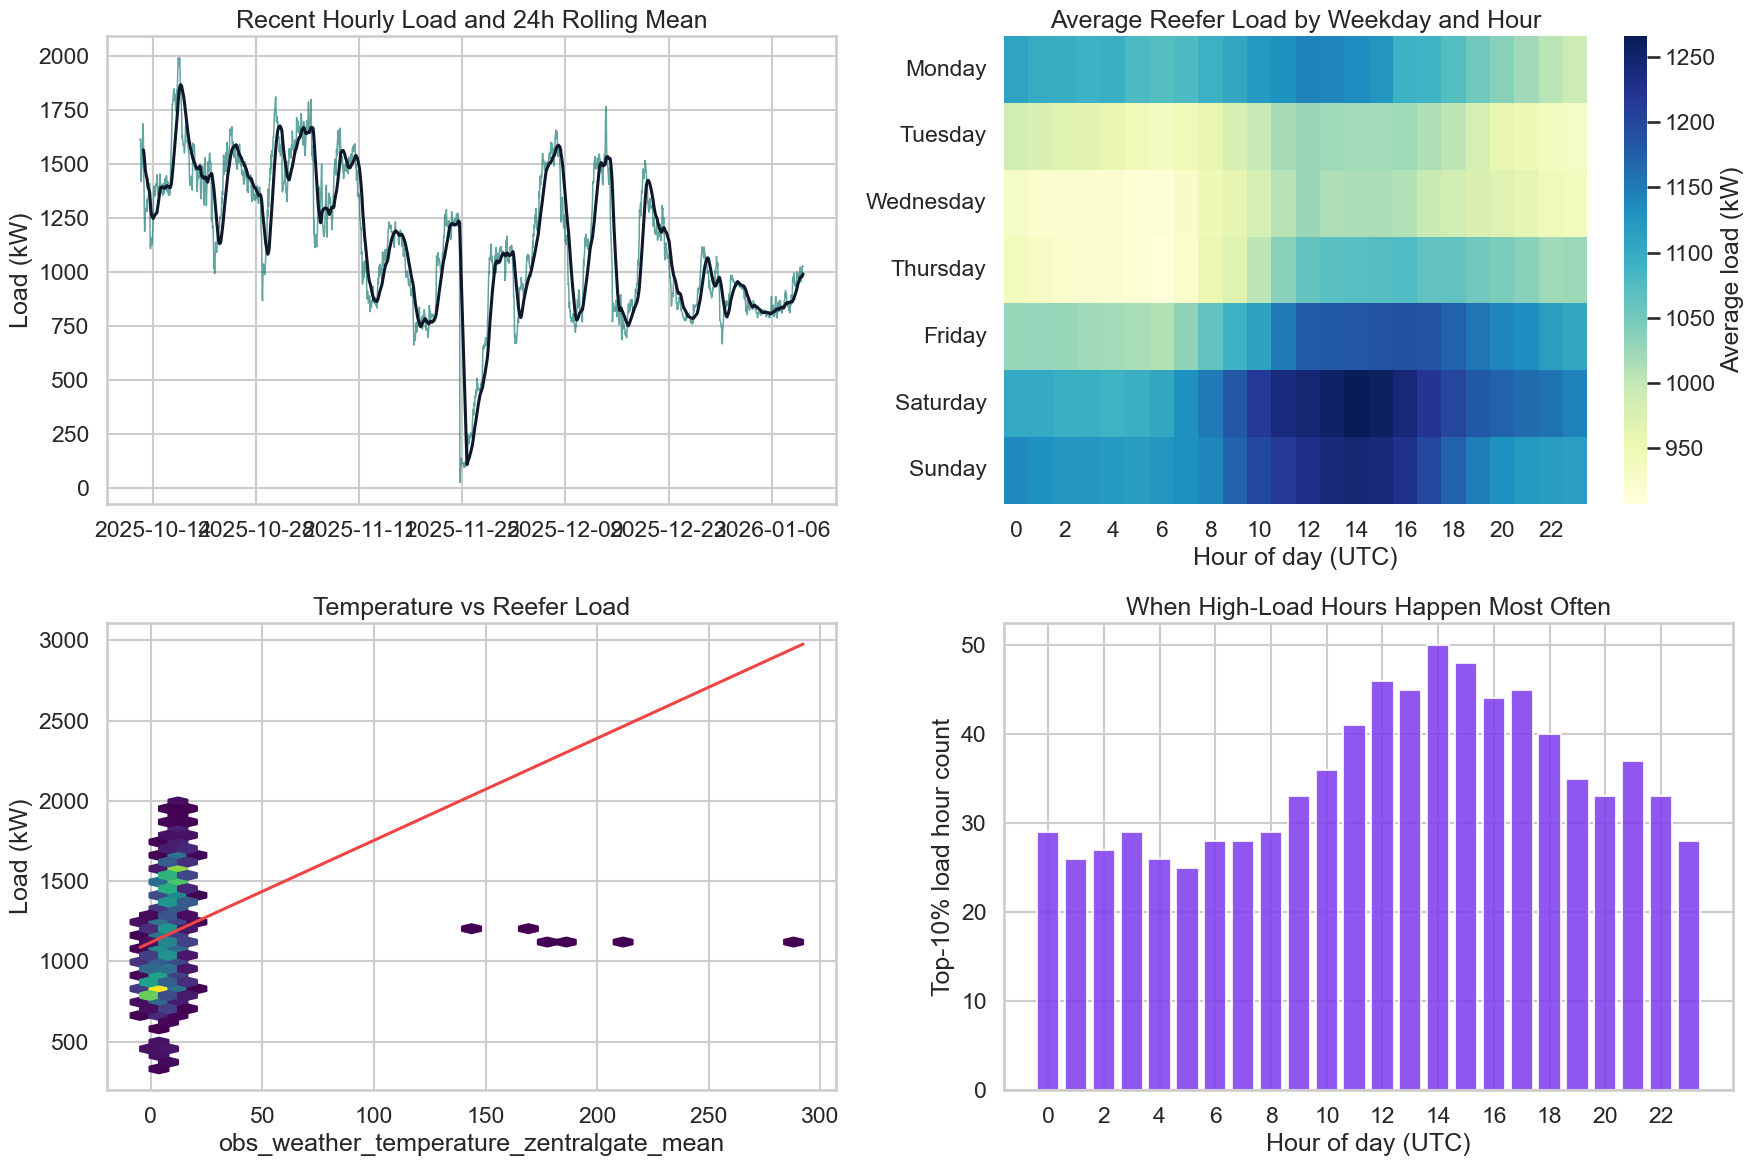

In [7]:
actual = feature_table['y_kw'].dropna()
recent = actual.loc[actual.index >= actual.index.max() - pd.Timedelta(days=90)]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].plot(recent.index, recent.values, color='#0f766e', linewidth=1.1, alpha=0.65)
axes[0, 0].plot(
    recent.index,
    recent.rolling(24, min_periods=12).mean(),
    color='#0f172a',
    linewidth=2.2,
)
axes[0, 0].set_title('Recent Hourly Load and 24h Rolling Mean')
axes[0, 0].set_ylabel('Load (kW)')
axes[0, 0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

heat = actual.to_frame('y_kw')
heat['hour'] = heat.index.hour
heat['weekday'] = heat.index.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heat.pivot_table(index='weekday', columns='hour', values='y_kw', aggfunc='mean').reindex(weekday_order)
sns.heatmap(heatmap_data, cmap='YlGnBu', ax=axes[0, 1], cbar_kws={'label': 'Average load (kW)'})
axes[0, 1].set_title('Average Reefer Load by Weekday and Hour')
axes[0, 1].set_xlabel('Hour of day (UTC)')
axes[0, 1].set_ylabel('')

temperature_candidates = [
    'obs_weather_temperature_zentralgate_mean',
    'obs_weather_temperature_vc_halle3_mean',
    'obs_temp_ambient_mean',
]
temp_col = next((col for col in temperature_candidates if col in feature_table.columns), None)
if temp_col is not None:
    scatter_sample = feature_table[[temp_col, 'y_kw']].dropna()
    if len(scatter_sample) > 12000:
        scatter_sample = scatter_sample.sample(12000, random_state=RANDOM_SEED)
    axes[1, 0].hexbin(scatter_sample[temp_col], scatter_sample['y_kw'], gridsize=35, cmap='viridis', mincnt=1)
    coeffs = np.polyfit(scatter_sample[temp_col], scatter_sample['y_kw'], deg=1)
    x_line = np.linspace(scatter_sample[temp_col].min(), scatter_sample[temp_col].max(), 100)
    axes[1, 0].plot(x_line, coeffs[0] * x_line + coeffs[1], color='#ef4444', linewidth=2.2)
    axes[1, 0].set_title('Temperature vs Reefer Load')
    axes[1, 0].set_xlabel(temp_col)
    axes[1, 0].set_ylabel('Load (kW)')

peak_threshold = actual.quantile(0.9)
peak_hours = actual[actual >= peak_threshold]
peak_hour_counts = peak_hours.groupby(peak_hours.index.hour).size().reindex(range(24), fill_value=0)
axes[1, 1].bar(peak_hour_counts.index, peak_hour_counts.values, color='#7c3aed', alpha=0.85)
axes[1, 1].set_title('When High-Load Hours Happen Most Often')
axes[1, 1].set_xlabel('Hour of day (UTC)')
axes[1, 1].set_ylabel('Top-10% load hour count')
axes[1, 1].set_xticks(range(0, 24, 2))

fig.tight_layout()
plt.show()


## 4. Train, validation, and submission split

This challenge behaves like a time-series forecasting task:

- **train / validation**: historical labeled hours used in rolling 7-day backtests
- **submission split**: public target timestamps where we need predictions

The notebook uses the same four rolling validation folds as the script pipeline.


In [8]:
model_rows = get_model_rows(feature_table)
submission_rows = feature_table.loc[feature_table['is_public_target']].copy()
folds = make_validation_folds(feature_table)

fold_summary = []
for fold_name, fold_start, fold_end in folds:
    train_rows = int((model_rows.index < fold_start).sum())
    valid_rows = int(((model_rows.index >= fold_start) & (model_rows.index <= fold_end)).sum())
    fold_summary.append(
        {
            'fold_name': fold_name,
            'train_start': model_rows.index.min(),
            'train_end': fold_start - pd.Timedelta(hours=1),
            'valid_start': fold_start,
            'valid_end': fold_end,
            'train_rows': train_rows,
            'valid_rows': valid_rows,
        }
    )

split_summary = pd.DataFrame(
    {
        'split': ['labeled_model_rows', 'submission_rows'],
        'rows': [len(model_rows), len(submission_rows)],
        'start': [model_rows.index.min(), submission_rows.index.min()],
        'end': [model_rows.index.max(), submission_rows.index.max()],
    }
)

display(split_summary)
display(pd.DataFrame(fold_summary))


,split,rows,start,end
0,labeled_model_rows,8067,2025-01-08,2026-01-10 06:00:00
1,submission_rows,223,2026-01-01,2026-01-10 06:00:00


,fold_name,train_start,train_end,valid_start,valid_end,train_rows,valid_rows
0,fold_1,2025-01-08,2025-12-13 06:00:00,2025-12-13 07:00:00,2025-12-20 06:00:00,7395,168
1,fold_2,2025-01-08,2025-12-20 06:00:00,2025-12-20 07:00:00,2025-12-27 06:00:00,7563,168
2,fold_3,2025-01-08,2025-12-27 06:00:00,2025-12-27 07:00:00,2026-01-03 06:00:00,7731,168
3,fold_4,2025-01-08,2026-01-03 06:00:00,2026-01-03 07:00:00,2026-01-10 06:00:00,7899,168


## 5. Build model

The modeling design is a two-stage forecast:

1. A strong baseline forecast: `0.7 * lag_24 + 0.3 * lag_168`
2. A `GradientBoostingRegressor` trained on the residual above that baseline

Peak hours receive higher sample weight during training, and `pred_p90_kw` is calibrated from positive validation residuals.


In [9]:
feature_columns = get_feature_columns(feature_table)
reference_train_frame = model_rows.loc[model_rows.index < folds[0][1]].copy()
selected_columns = select_training_columns(reference_train_frame, feature_columns)

model_design = pd.DataFrame(
    {
        'component': [
            'Baseline forecast',
            'Residual model',
            'Loss',
            'Peak weighting',
            'Preprocessing',
            'P90 calibration',
        ],
        'details': [
            '0.7 * lag_24 + 0.3 * lag_168',
            'GradientBoostingRegressor',
            'absolute_error',
            'Top 10% load hours weighted 2x',
            'median impute + clip + scale on training data only',
            'Positive residual q90 by hour and prediction bin',
        ],
    }
)

print(f'Total candidate feature columns: {len(feature_columns)}')
print(f'Informative feature columns in the first training fold: {len(selected_columns)}')
display(model_design)


Total candidate feature columns: 268
Informative feature columns in the first training fold: 264


,component,details
0,Baseline forecast,0.7 * lag_24 + 0.3 * lag_168
1,Residual model,GradientBoostingRegressor
2,Loss,absolute_error
3,Peak weighting,Top 10% load hours weighted 2x
4,Preprocessing,median impute + clip + scale on training data ...
5,P90 calibration,Positive residual q90 by hour and prediction bin


## 6. Train model

We now run the rolling backtest. Each fold trains the residual model on past data only, predicts the validation week, calibrates the p90 estimate, and stores the metrics.


In [10]:
fold_results, best_bundle, best_calibrator, best_result = run_backtest(feature_table)

metrics_payload = {
    'folds': serialize_fold_results(fold_results),
    'mean_metrics': summarize_fold_results(fold_results),
}
metrics_path = OUTPUT_DIR / 'backtest_metrics.json'
metrics_path.write_text(json.dumps(metrics_payload, indent=2), encoding='utf-8')

best_model_path = OUTPUT_DIR / 'best_model.pkl'
save_model_artifact(best_model_path, best_bundle, best_calibrator, best_result)

print(f'Saved backtest metrics to: {metrics_path}')
print(f'Saved best model artifact to: {best_model_path}')


fold_1: train_rows=7,395, valid_rows=168
fold_2: train_rows=7,563, valid_rows=168
fold_3: train_rows=7,731, valid_rows=168
fold_4: train_rows=7,899, valid_rows=168
Saved backtest metrics to: /Users/yash1010/Documents/GitHub/GDiM-Eurogate-Challenge/outputs/backtest_metrics.json
Saved best model artifact to: /Users/yash1010/Documents/GitHub/GDiM-Eurogate-Challenge/outputs/best_model.pkl


## 7. Evaluate model

The challenge evaluates overall accuracy, peak-hour accuracy, and the usefulness of the p90 upper estimate. Lower values are better.


In [11]:
fold_metrics_df = pd.DataFrame(serialize_fold_results(fold_results))
mean_metrics_df = pd.DataFrame([summarize_fold_results(fold_results)])

display(fold_metrics_df)
display(mean_metrics_df)


,fold_name,train_rows,valid_rows,mae_all,mae_peak,pinball_p90,score
0,fold_1,7395,168,199.169573,96.311404,38.588544,136.195917
1,fold_2,7563,168,112.880879,220.113936,18.274458,126.129512
2,fold_3,7731,168,94.537843,135.135372,14.867364,90.783006
3,fold_4,7899,168,45.029192,57.886731,8.356304,41.551876


,mae_all,mae_peak,pinball_p90,score
0,112.904372,127.36186,20.021668,98.665078


## 8. Pick the best model

The best model is the fold with the **lowest combined score**. We keep that fold's trained model bundle and p90 calibrator, then export the model-ready feature table and preprocessing summary.


In [12]:
model_ready = build_model_ready_feature_table(feature_table, best_bundle.preprocessor)
model_ready_path = OUTPUT_DIR / 'model_ready_feature_table.csv'
model_ready.reset_index().to_csv(model_ready_path, index=False)

preprocessing_info = preprocessing_summary(best_bundle.preprocessor)
preprocessing_summary_path = OUTPUT_DIR / 'preprocessing_summary.json'
preprocessing_summary_path.write_text(json.dumps(preprocessing_info, indent=2), encoding='utf-8')

best_model_summary = pd.DataFrame(
    {
        'metric': ['fold_name', 'mae_all', 'mae_peak', 'pinball_p90', 'score'],
        'value': [
            best_result.fold_name,
            round(best_result.mae_all, 3),
            round(best_result.mae_peak, 3),
            round(best_result.pinball_p90, 3),
            round(best_result.score, 3),
        ],
    }
)

display(best_model_summary)
print(f'Saved model-ready features to: {model_ready_path}')
print(f'Saved preprocessing summary to: {preprocessing_summary_path}')


,metric,value
0,fold_name,fold_4
1,mae_all,45.029
2,mae_peak,57.887
3,pinball_p90,8.356
4,score,41.552


Saved model-ready features to: /Users/yash1010/Documents/GitHub/GDiM-Eurogate-Challenge/outputs/model_ready_feature_table.csv
Saved preprocessing summary to: /Users/yash1010/Documents/GitHub/GDiM-Eurogate-Challenge/outputs/preprocessing_summary.json


## 9. Create `predictions.csv` for submission

Finally, we use the selected best model and calibrator to predict all public target timestamps and write a submission file that matches the required format.


In [13]:
submission = generate_submission(feature_table, best_bundle, best_calibrator)
predictions_path = ROOT / 'predictions.csv'
submission.to_csv(predictions_path, index=False)

risk_buffer = submission['pred_p90_kw'] - submission['pred_power_kw']
submission_summary = pd.DataFrame(
    {
        'metric': ['rows', 'forecast_start', 'forecast_end', 'mean_pred_power_kw', 'mean_pred_p90_kw', 'mean_risk_buffer_kw'],
        'value': [
            len(submission),
            submission['timestamp_utc'].min(),
            submission['timestamp_utc'].max(),
            round(float(submission['pred_power_kw'].mean()), 3),
            round(float(submission['pred_p90_kw'].mean()), 3),
            round(float(risk_buffer.mean()), 3),
        ],
    }
)

display(submission.head(10))
display(submission_summary)
print(f'Saved submission file to: {predictions_path}')


,timestamp_utc,pred_power_kw,pred_p90_kw
0,2026-01-01T00:00:00Z,941.558233,986.471691
1,2026-01-01T01:00:00Z,925.778932,982.899253
2,2026-01-01T02:00:00Z,941.053719,981.623264
3,2026-01-01T03:00:00Z,959.980034,1013.690524
4,2026-01-01T04:00:00Z,957.599241,1027.322895
5,2026-01-01T05:00:00Z,927.919144,1000.932552
6,2026-01-01T06:00:00Z,875.783957,945.109488
7,2026-01-01T07:00:00Z,887.282416,933.155161
8,2026-01-01T08:00:00Z,905.006466,939.172990
9,2026-01-01T09:00:00Z,914.642287,955.140737


,metric,value
0,rows,223
1,forecast_start,2026-01-01T00:00:00Z
2,forecast_end,2026-01-10T06:00:00Z
3,mean_pred_power_kw,885.236
4,mean_pred_p90_kw,934.812
5,mean_risk_buffer_kw,49.576


Saved submission file to: /Users/yash1010/Documents/GitHub/GDiM-Eurogate-Challenge/predictions.csv
